In [2]:
#### 
## This project focuses on credit card fraud detection using deep learning.
## The dataset was taken from Kaggle and contains highly imbalanced transaction data.
## The main objective is to build a neural network model that can classify fraudulent and non-fraudulent transactions.
### fraud cases are rare, the project also pays attention to suitable evaluation metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



In [4]:
!pip install kagglehub
import kagglehub

In [5]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset folder:", path)
csv_file = list(Path(path).rglob("*.csv"))[0]
print("CSV file:", csv_file)
df = pd.read_csv(csv_file)
df.head()

Dataset folder: C:\Users\Admin\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
CSV file: C:\Users\Admin\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset info:")
print(df.info())

Shape of dataset: (284807, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float6

In [7]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [8]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1081


In [9]:
# Remove duplicates 
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [10]:
print("Class distribution:")
print(df["Class"].value_counts())

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [11]:
print("Class percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Class percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [12]:
fraud_rate = df["Class"].mean() * 100
print("Fraud rate:", round(fraud_rate, 4), "%")

Fraud rate: 0.1667 %


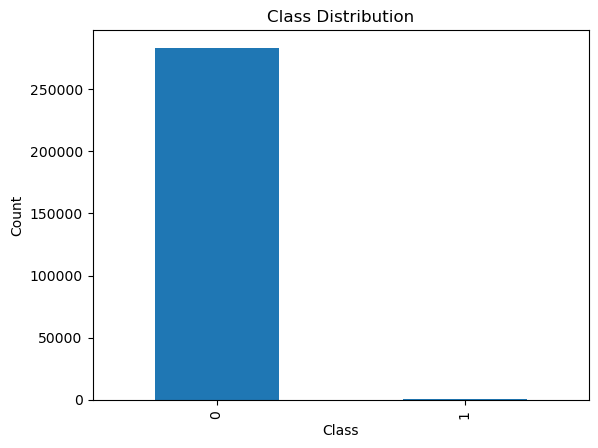

In [13]:
#### EDA 
## Class distribution
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

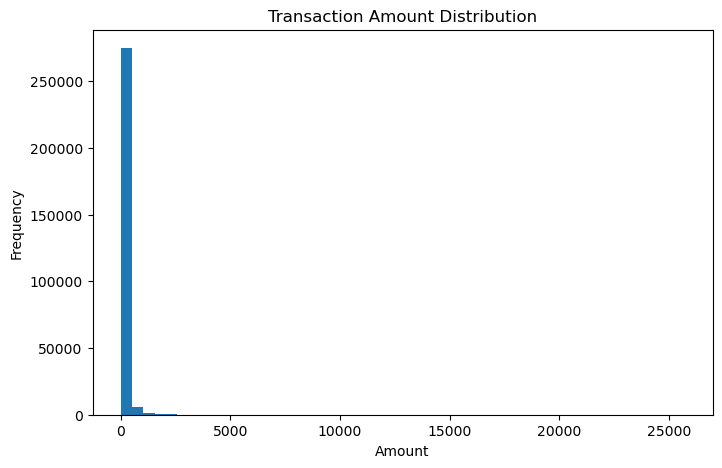

In [14]:
#### Transaction amount distribution
plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

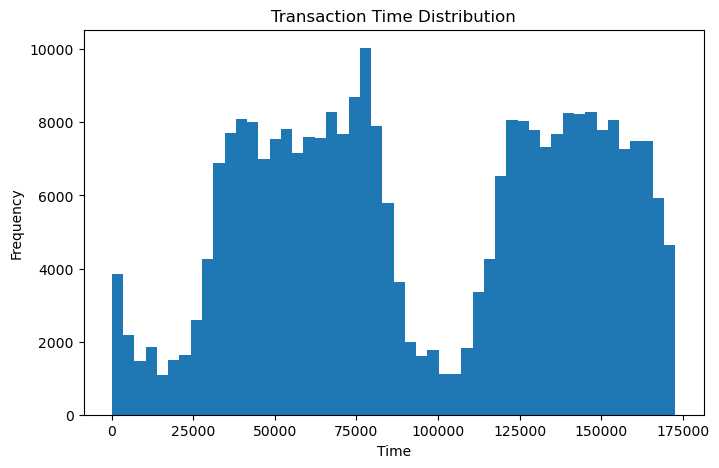

In [15]:
### Transaction and time distribution
plt.figure(figsize=(8,5))
plt.hist(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

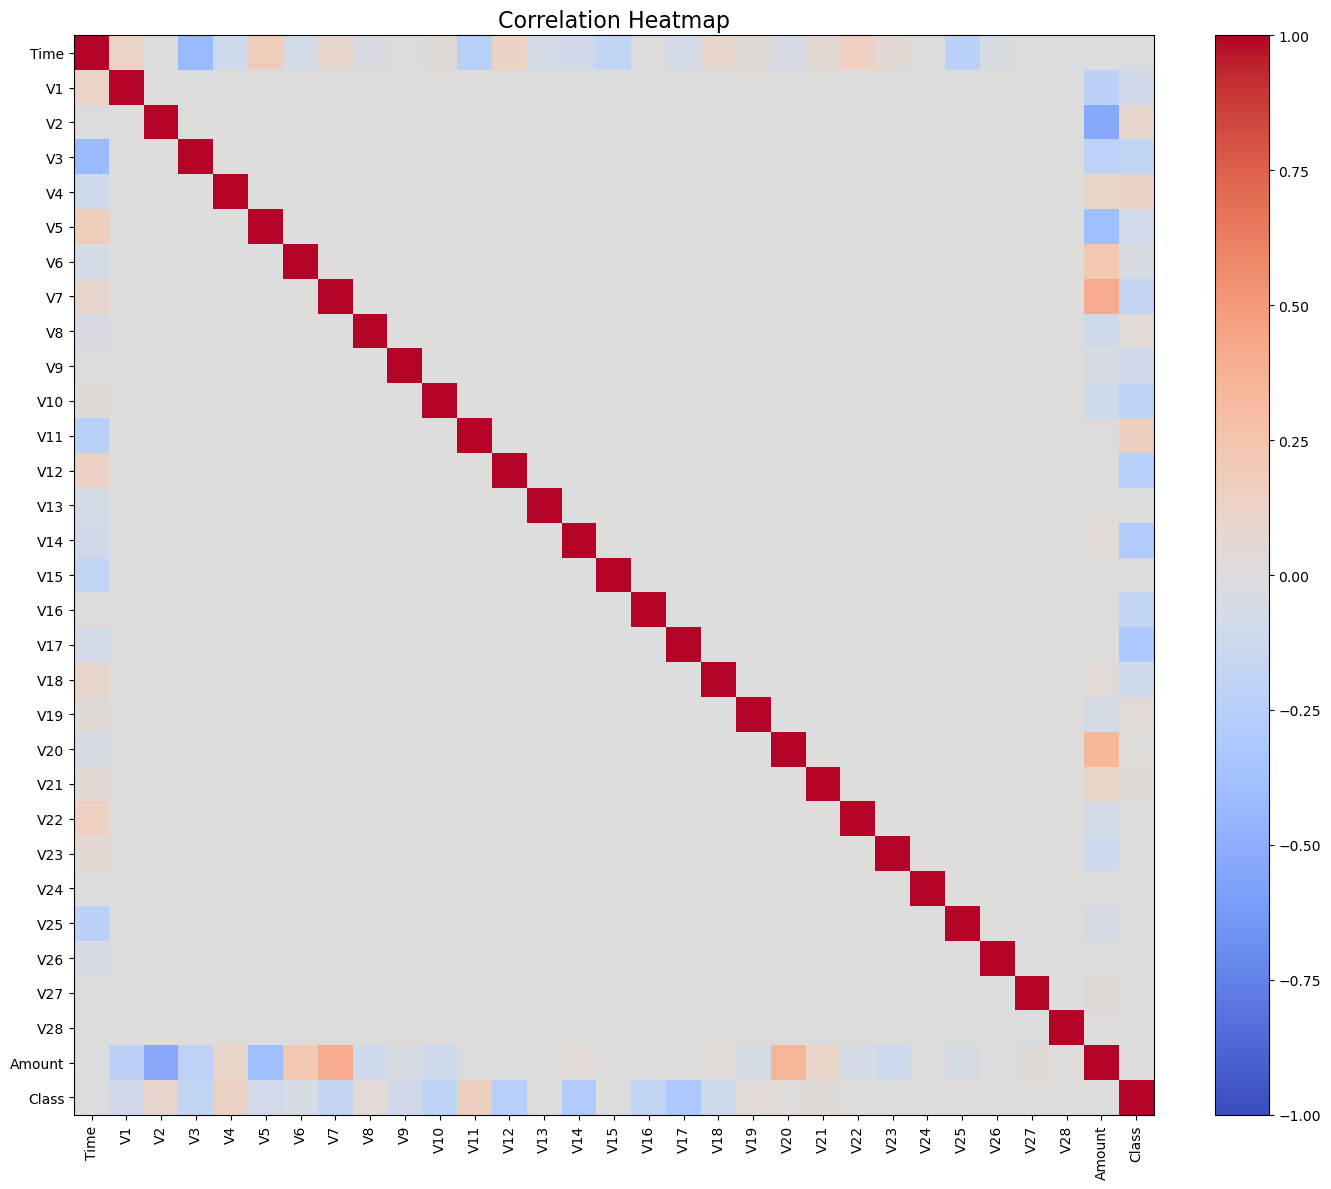

In [16]:
#### Correlation 
corr = df.corr()
plt.figure(figsize=(16, 12))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr.columns)), labels=corr.columns)
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
###
### The dataset is highly imbalanced because fraud transactions are much fewer than normal transactions.
##This means accuracy alone is not enough to evaluate the model.
### Amount and Time have different scales, so they should be standardized before training.

In [18]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [19]:
### Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (226980, 30)
X_test shape: (56746, 30)
y_train shape: (226980,)
y_test shape: (56746,)


In [20]:
### Scale 
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,1.045499,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,-0.229434
134253,-0.298690,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,-0.331197
186465,0.678397,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,-0.298809
149493,-0.074929,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,-0.289247
18461,-1.376728,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,-0.261985


In [21]:
### PREPROCESSING 
##I standardized the Time and Amount columns because they are not on the same scale.
### Other features were already transformed in the dataset.


In [22]:
######### Handle imbalanced data using class weights
neg, pos = np.bincount(y_train)
total = neg + pos

weight_for_0 = total / (2 * neg)
weight_for_1 = total / (2 * pos)

class_weight = {0: weight_for_0, 1: weight_for_1}

print("Class weights:", class_weight)

Class weights: {0: np.float64(0.5008340614822464), 1: np.float64(300.23809523809524)}


In [23]:
#### I have not formally learned this method yet in class, but I tried to explore it because this dataset has a serious class imbalance problem.
## I used it in this project because fraud cases are rare, and without it the model may focus too much on normal transactions.
### The goal was to make the model pay more attention to fraud detection.
    

In [24]:
### Build the model 
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
### Train model 
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8121 - loss: 0.4196 - val_accuracy: 0.9527 - val_loss: 0.3430
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9446 - loss: 0.2831 - val_accuracy: 0.9683 - val_loss: 0.2222
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9633 - loss: 0.2151 - val_accuracy: 0.9739 - val_loss: 0.1637
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9666 - loss: 0.1971 - val_accuracy: 0.9705 - val_loss: 0.1514
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9646 - loss: 0.1758 - val_accuracy: 0.9782 - val_loss: 0.1174
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9722 - loss: 0.1636 - val_accuracy: 0.9762 - val_loss: 0.1161
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9650 - loss: 0.1590 - val_accuracy: 0.9772 - val_loss: 0.1053
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9723 - loss: 0.1465 - val_accuracy: 0.9750 - val_loss

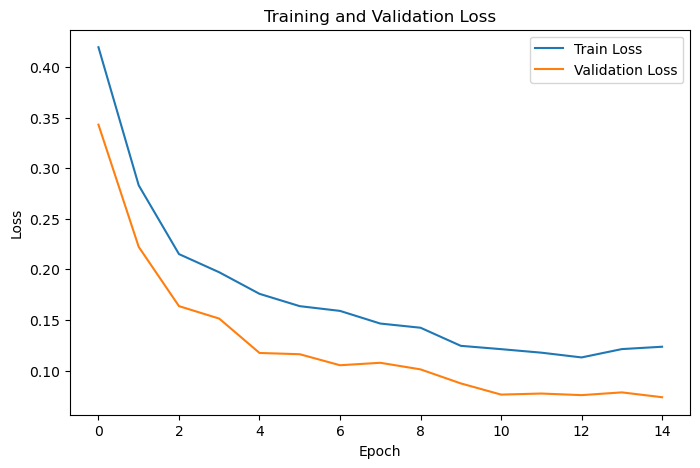

In [28]:
#### Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

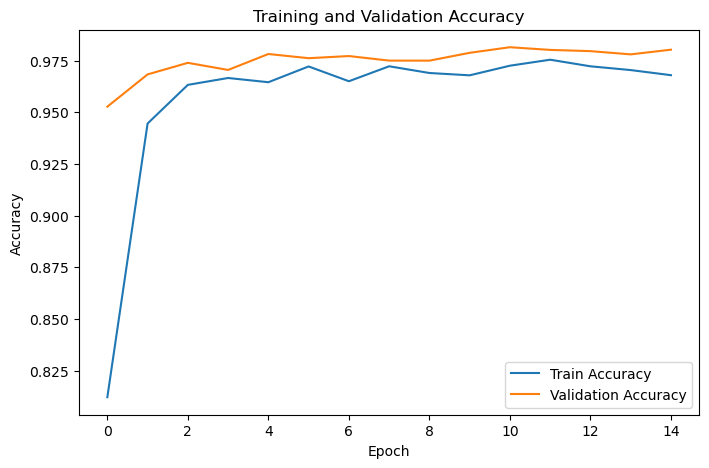

In [29]:
#### Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [30]:
### Make 
y_prob = model.predict(X_test)
y_prob = y_prob.flatten()

y_pred = (y_prob >= 0.5).astype(int)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [31]:
## Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:

              precision    recall  f1-score   support

           0     0.9998    0.9801    0.9898     56651
           1     0.0679    0.8632    0.1259        95

    accuracy                         0.9799     56746
   macro avg     0.5338    0.9216    0.5579     56746
weighted avg     0.9982    0.9799    0.9884     56746



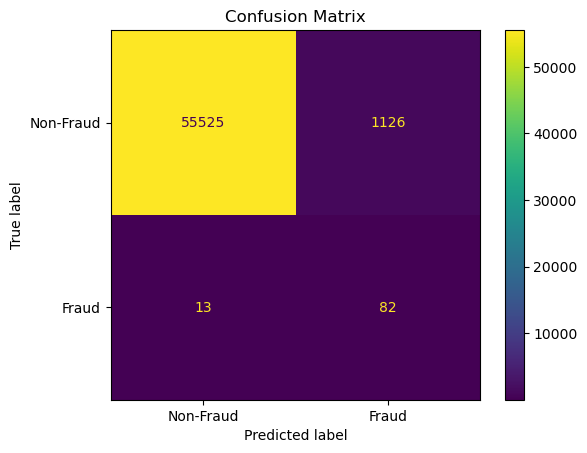

In [33]:
#### Confusion matrix 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
### Other metrics
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("Accuracy :", round((y_pred == y_test).mean(), 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))
print("PR-AUC   :", round(pr_auc, 4))

In [ ]:
## The accuracy kinda low here but Accuracy is not the most important metric here because the dataset is highly imbalanced. 
## and I use ROC-AUC and PR-AUC are useful for evaluating performance on imbalanced data.


In [34]:
# try another threshold to detect more fraud cases
y_pred_03 = (y_prob >= 0.3).astype(int)

print("Classification Report with threshold = 0.3\n")
print(classification_report(y_test, y_pred_03, digits=4))

Classification Report with threshold = 0.3

              precision    recall  f1-score   support

           0     0.9998    0.9579    0.9784     56651
           1     0.0344    0.8947    0.0663        95

    accuracy                         0.9578     56746
   macro avg     0.5171    0.9263    0.5224     56746
weighted avg     0.9982    0.9578    0.9769     56746



In [ ]:
##### I increased the threshold to 0.3 so the model becomes more strict when predicting fraud. This improved precision, which means fewer normal transactions were incorrectly flagged as fraud. 
## However, recall decreased slightly because some fraud cases were missed.

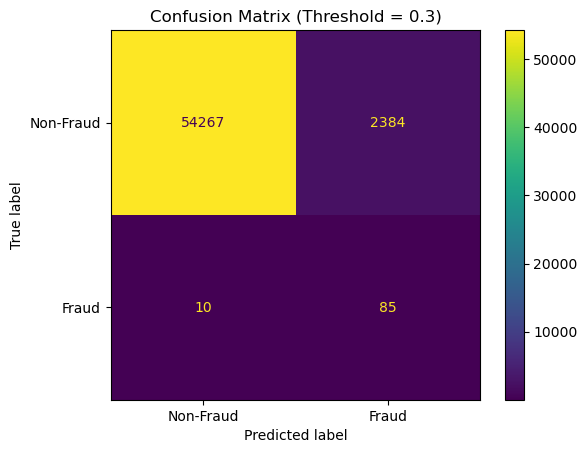

In [43]:
cm_03 = confusion_matrix(y_test, y_pred_03)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_03, display_labels=["Non-Fraud", "Fraud"])
disp.plot()
plt.title("Confusion Matrix (Threshold = 0.3)")
plt.show()

In [42]:
precision_03 = precision_score(y_test, y_pred_03, zero_division=0)
recall_03 = recall_score(y_test, y_pred_03, zero_division=0)
f1_03 = f1_score(y_test, y_pred_03, zero_division=0)

print("Precision at 0.3:", round(precision_03, 4))
print("Recall at 0.3   :", round(recall_03, 4))
print("F1-score at 0.3 :", round(f1_03, 4))

Precision at 0.3: 0.0344
Recall at 0.3   : 0.8947
F1-score at 0.3 : 0.0663


In [40]:
print(""" limitations:
1. The dataset is highly imbalanced, so the model may favor non-fraud transactions.
2. False negatives are risky because real fraud may be missed.
3. False positives may block normal customer transactions and cause inconvenience.
4. The variables V1 to V28 are anonymized, so the model is less interpretable.
5. The dataset is old and may not represent all current fraud patterns.
""")

 limitations:
1. The dataset is highly imbalanced, so the model may favor non-fraud transactions.
2. False negatives are risky because real fraud may be missed.
3. False positives may block normal customer transactions and cause inconvenience.
4. The variables V1 to V28 are anonymized, so the model is less interpretable.
5. The dataset is old and may not represent all current fraud patterns.



In [41]:
print("""
Conclusion:
This project built a deep learning model to detect fraudulent credit card transactions.
The data was cleaned, explored, and preprocessed before training.
A neural network with dropout was used as the main model.
Because the dataset is highly imbalanced, class weights were applied and multiple metrics were used for evaluation.
Overall, this project shows a complete deep learning workflow for a real-world fraud detection problem.
""")


Conclusion:
This project built a deep learning model to detect fraudulent credit card transactions.
The data was cleaned, explored, and preprocessed before training.
A neural network with dropout was used as the main model.
Because the dataset is highly imbalanced, class weights were applied and multiple metrics were used for evaluation.
Overall, this project shows a complete deep learning workflow for a real-world fraud detection problem.

